In [71]:
import movement
from movement.io import load_dataset
from movement.filtering import filter_by_confidence, interpolate_over_time, rolling_filter, savgol_filter
from movement.kinematics import compute_velocity, compute_forward_vector, compute_forward_vector_angle
from pathlib import Path
import numpy as np
from movement.plots import plot_centroid_trajectory
from movement.utils.vector import cart2pol, pol2cart

import matplotlib.pyplot as plt
from scipy.signal import welch

In [4]:
Path.home()

WindowsPath('C:/Users/saram')

In [5]:
file_name = "T1_1D_04032026_inference.slp"
file_dir = Path.home() / "Desktop"/ "CollaborationDays"
file_path = file_dir/file_name
file_path.exists()

True

In [8]:
ds=load_dataset(file_path, fps=25)

In [9]:
ds

<xarray.Dataset> Size: 281kB
Dimensions:     (time: 4135, space: 2, keypoint: 5, individual: 1)
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U9 180B 'snout' 'right_ear' ... 'center' 'headcap'
  * individual  (individual) <U4 16B 'id_0'
Data variables:
    position    (time, space, keypoint, individual) float32 165kB nan ... nan
    confidence  (time, keypoint, individual) float32 83kB 0.0 0.9264 ... nan nan
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    fps:              25.0
    time_unit:        seconds
    source_file:      C:/Users/saram/Desktop/CollaborationDays/T1_1D_04032026...

In [19]:
ds_headcap=ds.sel(keypoint=["headcap"])

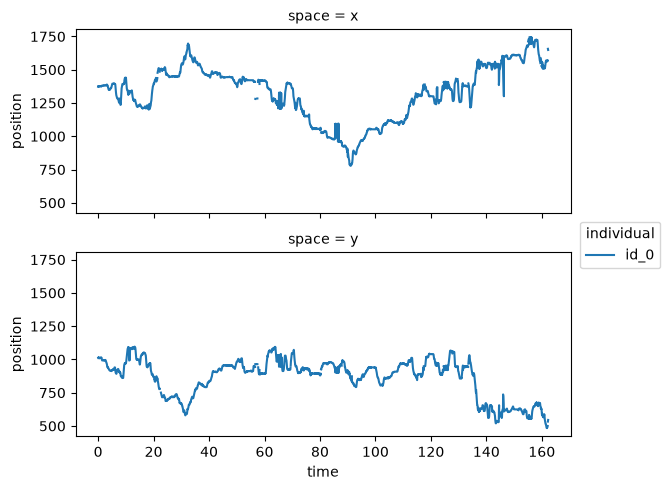

In [20]:
#we want to see the position of the headcap across space
headcap_pos=ds.position.sel(keypoint="headcap")
headcap_pos.plot.line(x="time", hue="individual", row="space", aspect=2, size=2.5)

(array([ 117.,    0.,    0.,   17.,   97.,  118.,  101.,  111.,  108.,
          88.,   99.,   86.,   74.,   74.,  103.,  132.,  316., 1562.,
         803.,   52.]),
 array([0.        , 0.05287459, 0.10574917, 0.15862375, 0.21149835,
        0.26437294, 0.31724751, 0.3701221 , 0.4229967 , 0.47587129,
        0.52874589, 0.58162045, 0.63449502, 0.68736964, 0.74024421,
        0.79311883, 0.8459934 , 0.89886796, 0.95174259, 1.00461721,
        1.05749178]),
 <BarContainer object of 20 artists>)

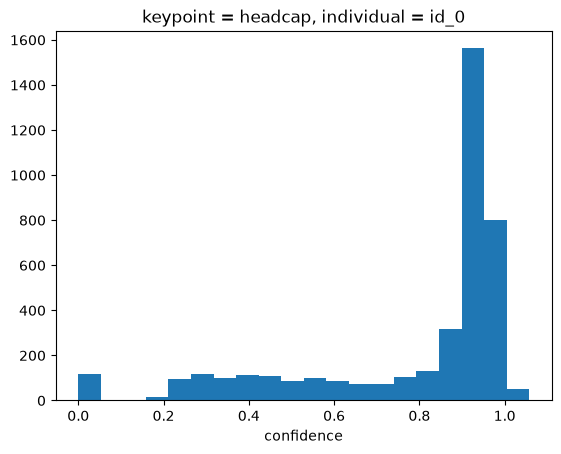

In [21]:
#Inspect outliers
ds_headcap.confidence.squeeze().plot.hist(bins=20)

In [60]:
#Filter outliers (every keypoint)
ds.update(
    {
        "position": filter_by_confidence(
            ds.position, ds.confidence, threshold=0.8, print_report=True
        )
    }
)

Missing points (marked as NaN) in input:

keypoint                 snout          right_ear           left_ear           center           headcap
individual                                                                                             
id_0        3965/4135 (95.89%)  567/4135 (13.71%)  576/4135 (13.93%)  77/4135 (1.86%)  194/4135 (4.69%)
Missing points (marked as NaN) in output:

keypoint                 snout           right_ear            left_ear           center            headcap
individual                                                                                                
id_0        4129/4135 (99.85%)  1293/4135 (31.27%)  1486/4135 (35.94%)  77/4135 (1.86%)  1282/4135 (31.0%)


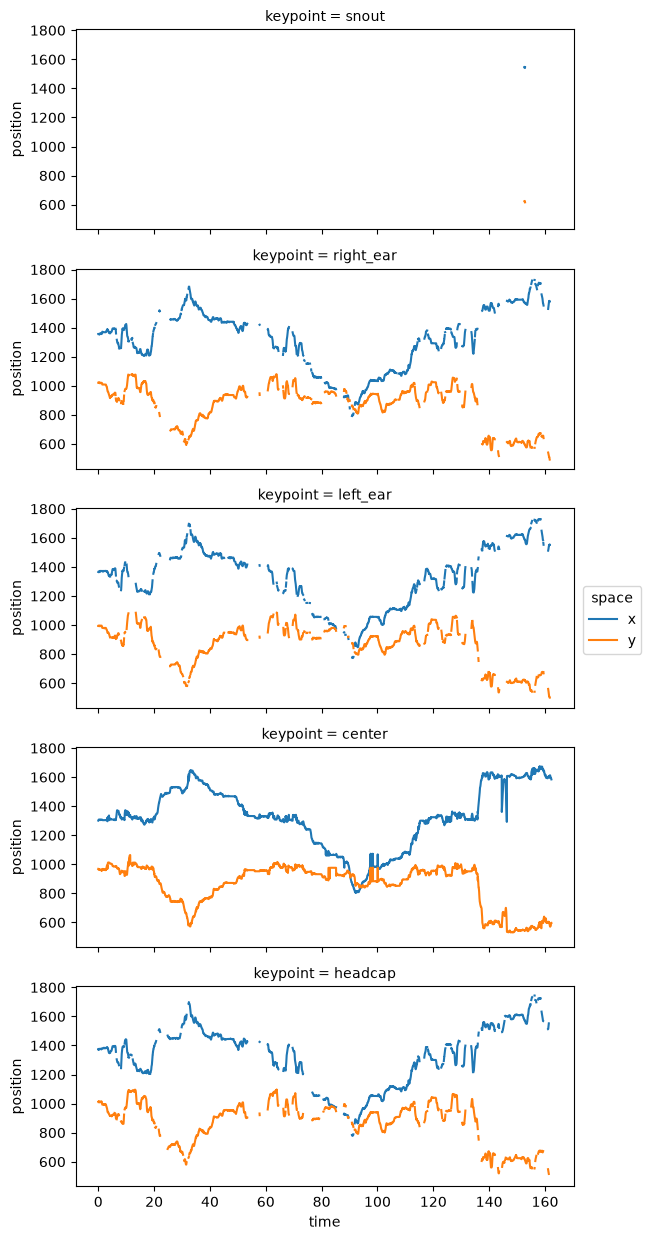

In [62]:
#Check filtering
ds.position.squeeze().plot.line(
    x="time", row="keypoint", hue="space", aspect=2, size=2.5
)

In [63]:
#Interpolate filtered data
ds.update(
    {
        "position": interpolate_over_time(
            ds.position, max_gap=40, print_report=True
        )
    }
)

Missing points (marked as NaN) in input:

keypoint                 snout           right_ear            left_ear           center            headcap
individual                                                                                                
id_0        4129/4135 (99.85%)  1293/4135 (31.27%)  1486/4135 (35.94%)  77/4135 (1.86%)  1282/4135 (31.0%)
Missing points (marked as NaN) in output:

keypoint                 snout          right_ear           left_ear           center            headcap
individual                                                                                              
id_0        4126/4135 (99.78%)  578/4135 (13.98%)  603/4135 (14.58%)  77/4135 (1.86%)  655/4135 (15.84%)


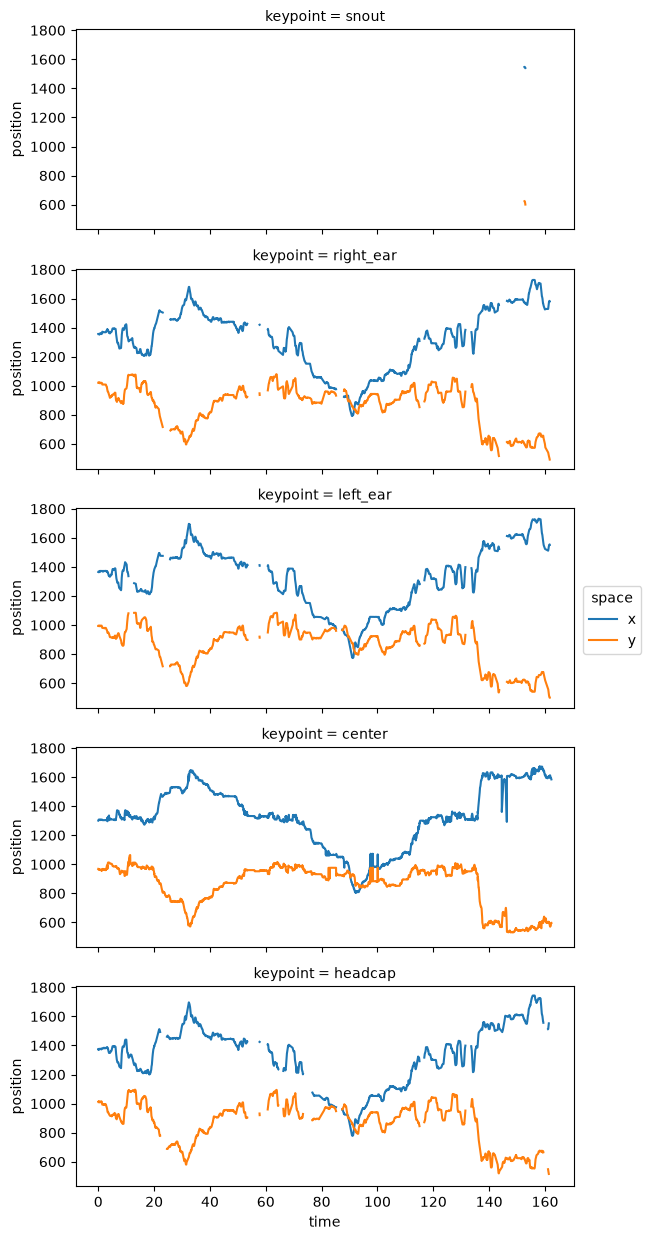

In [64]:
#Check interpolation
ds.position.squeeze().plot.line(
    x="time", row="keypoint", hue="space", aspect=2, size=2.5
)

In [65]:
#Generate pipeline log
print(ds.position.log)

[
  {
    "operation": "filter_by_confidence",
    "datetime": "2026-08-21 14:48:58.754745",
    "confidence": "<xarray.DataArray 'confidence' (time: 4135, keypoint: 5, individual: 1)> Size: 83kB\n0.0 0.9264 0.9678 0.9671 0.9351 0.0 0.9788 1.003 ... nan nan nan nan nan nan nan\nCoordinates:\n  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4\n  * keypoint    (keypoint) <U9 180B 'snout' 'right_ear' ... 'center' 'headcap'\n  * individual  (individual) <U4 16B 'id_0'",
    "threshold": "0.8",
    "print_report": "True"
  },
  {
    "operation": "interpolate_over_time",
    "datetime": "2026-08-21 14:49:46.549587",
    "method": "'linear'",
    "max_gap": "40",
    "print_report": "True"
  }
]


In [66]:
#smoothing the tracking
window=int(0.3*ds.fps)
ds_smooth=ds.copy ()
ds_smooth.update({"position":rolling_filter(ds.position, window, min_periods=2, statistic="median", print_report=True)})

Missing points (marked as NaN) in input:

keypoint                 snout          right_ear           left_ear           center            headcap
individual                                                                                              
id_0        4126/4135 (99.78%)  578/4135 (13.98%)  603/4135 (14.58%)  77/4135 (1.86%)  655/4135 (15.84%)
Missing points (marked as NaN) in output:

keypoint                 snout          right_ear           left_ear           center            headcap
individual                                                                                              
id_0        4122/4135 (99.69%)  548/4135 (13.25%)  569/4135 (13.76%)  75/4135 (1.81%)  617/4135 (14.92%)


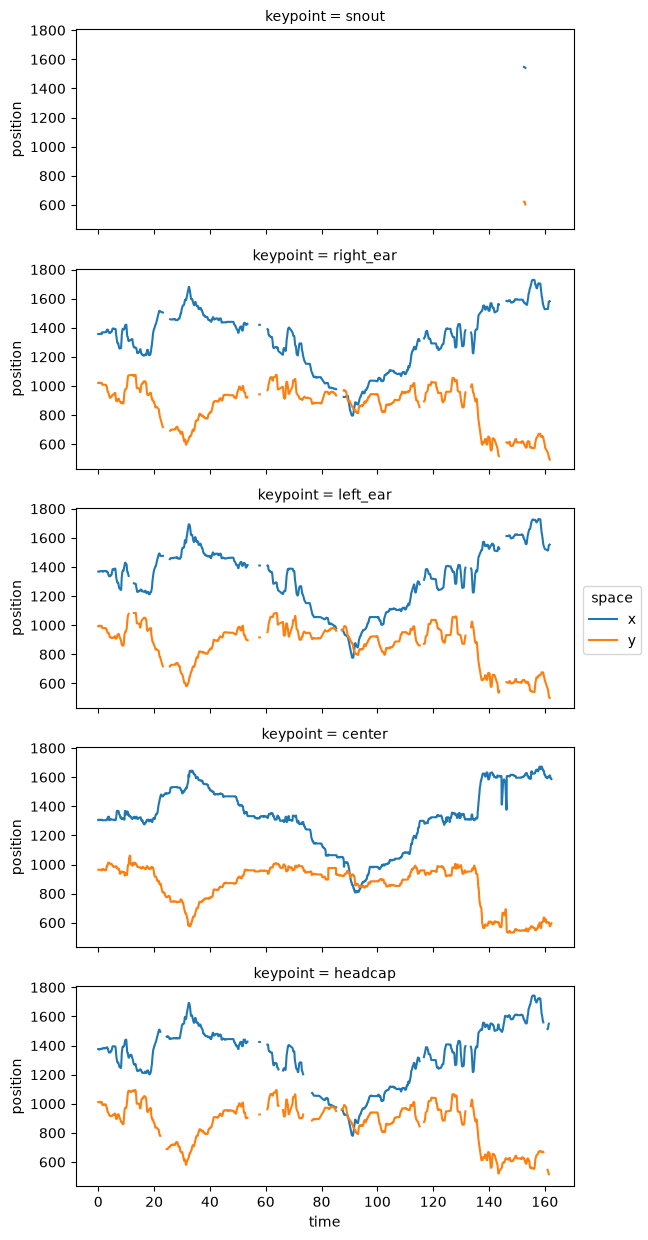

In [68]:
#plotting the output of the smoothing
ds_smooth.position.squeeze().plot.line(
    x="time", row="keypoint", hue="space", aspect=2, size=2.5
)

In [69]:
ds_smooth.position

<xarray.DataArray 'position' (time: 4135, space: 2, keypoint: 5, individual: 1)> Size: 165kB
nan 1.357e+03 1.369e+03 1.305e+03 1.376e+03 nan ... nan nan nan nan nan nan
Coordinates:
  * time        (time) float64 33kB 0.0 0.04 0.08 0.12 ... 165.3 165.3 165.4
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U9 180B 'snout' 'right_ear' ... 'center' 'headcap'
  * individual  (individual) <U4 16B 'id_0'
Attributes:
    log:      [\n  {\n    "operation": "filter_by_confidence",\n    "datetime...

AttributeError: 'Dataset' object has no attribute 'frame_path'

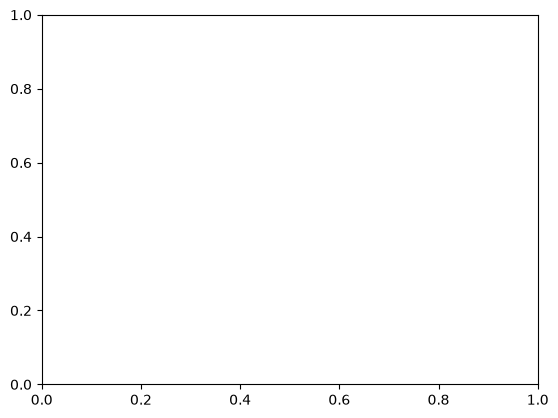

In [72]:
#compute head direction
# Create figure and axis
fig, ax = plt.subplots(1, 1)

# Plot a single frame from the dataset (its path is stored as an attribute)
frame = plt.imread(ds_smooth.frame_path)
ax.imshow(frame)

# Plot the trajectory of the head centre
plot_centroid_trajectory(
    ds_smooth.position,
    keypoints=["left_ear", "right_ear"],
    ax=ax,
    # arguments forwarded to plt.scatter
    s=10,
    cmap="viridis",
    marker="o",
    alpha=0.05,
)

# Adjust title
ax.set_title("Head trajectory")
ax.set_ylim(frame.shape[0], 0)  # match y-axis limits to image coordinates
ax.set_xlabel("x (pixels)")
ax.set_ylabel("y (pixels)")
ax.collections[0].colorbar.set_label("Time (seconds)")
fig.show()